In [1]:
import numpy as np
import os
dataset_path = "/kaggle/input/garbage-dataset/garbage_classification"
classes = os.listdir(dataset_path)
print (f"Classes found: {classes}")
image_paths, labels = [], []
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(label)

Classes found: ['metal', 'Plastic-bag', 'white-glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'Bottle']


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2
import tensorflow as tf
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from skimage import feature
import numpy as np
import warnings
warnings.filterwarnings('ignore')

2026-01-19 14:35:39.411735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768833339.600180      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768833339.654400      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768833340.117391      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768833340.117437      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768833340.117440      55 computation_placer.cc:177] computation placer alr

In [3]:
import cv2
import numpy as np
from skimage import feature
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# --- CẤU HÌNH LBP ---
# radius: Bán kính của vùng lân cận (vd: 1, 2, 3)
# n_points: Số lượng điểm lấy mẫu trong vùng lân cận (vd: 8, 16, 24)
RADIUS = 3
N_POINTS = RADIUS * 8 

# Hàm tính LBP
def compute_lbp_features(image_path, resize_size=(128, 128)):
    """
    Tính LBP Histogram (dùng phương pháp Uniform LBP) từ ảnh.
    """
    try:
        # 1. Đọc ảnh và chuyển sang ảnh xám (LBP hoạt động tốt nhất trên ảnh xám)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        
        # 2. Resize ảnh về kích thước cố định
        img = cv2.resize(img, resize_size)
        
        # 3. Tính LBP
        # 'uniform': Đảm bảo vector đặc trưng có kích thước cố định, giảm nhiễu
        lbp_image = feature.local_binary_pattern(
            img, 
            N_POINTS, 
            RADIUS, 
            method="uniform"
        )
        
        # 4. Tính Histogram của LBP image
        # Hàm np.histogram sẽ tính tần suất xuất hiện của các giá trị LBP
        (hist, _) = np.histogram(
            lbp_image.ravel(),
            bins=np.arange(0, N_POINTS + 3), # Số lượng bins = N_POINTS + 2 (vì LBP uniform)
            range=(0, N_POINTS + 2)
        )
        
        # 5. Chuẩn hóa Histogram
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7) # Chuẩn hóa và tránh chia cho 0
        
        return hist
    
    except Exception as e:
        # print(f"Lỗi xử lý LBP cho {image_path}: {e}")
        return None

# THAY THẾ BƯỚC TÍNH ĐẶC TRƯNG

# Tính đặc trưng LBP cho tất cả ảnh
print("\nĐang tính LBP features...")
lbp_features_list = []
valid_labels = []
valid_image_paths = [] 

# ... (Vòng lặp for img_path, label trong zip(image_paths, labels)):
for idx, (img_path, label) in enumerate(zip(image_paths, labels)):
    if idx % 500 == 0:
        print(f"Đã xử lý {idx}/{len(image_paths)}")
    
    # *** GỌI HÀM TÍNH LBP FEATURES ***
    lbp_feat = compute_lbp_features(img_path) 
    
    if lbp_feat is not None:
        lbp_features_list.append(lbp_feat)
        valid_labels.append(label)
        valid_image_paths.append(img_path)

# Chuyển thành numpy array
X = np.array(lbp_features_list)
y = np.array(valid_labels)

# Kích thước LBP sẽ là N_POINTS + 2 (ví dụ: 3*8+2 = 26 chiều)
print(f"\nLBP features shape: {X.shape}") 
print(f"Labels shape: {y.shape}")
print(f"Số lượng class: {len(set(y))}")


Đang tính LBP features...
Đã xử lý 0/15376
Đã xử lý 500/15376
Đã xử lý 1000/15376
Đã xử lý 1500/15376
Đã xử lý 2000/15376
Đã xử lý 2500/15376
Đã xử lý 3000/15376
Đã xử lý 3500/15376
Đã xử lý 4000/15376
Đã xử lý 4500/15376
Đã xử lý 5000/15376
Đã xử lý 5500/15376
Đã xử lý 6000/15376
Đã xử lý 6500/15376
Đã xử lý 7000/15376
Đã xử lý 7500/15376
Đã xử lý 8000/15376
Đã xử lý 8500/15376
Đã xử lý 9000/15376
Đã xử lý 9500/15376
Đã xử lý 10000/15376
Đã xử lý 10500/15376
Đã xử lý 11000/15376
Đã xử lý 11500/15376
Đã xử lý 12000/15376
Đã xử lý 12500/15376
Đã xử lý 13000/15376
Đã xử lý 13500/15376
Đã xử lý 14000/15376
Đã xử lý 14500/15376
Đã xử lý 15000/15376

LBP features shape: (15376, 26)
Labels shape: (15376,)
Số lượng class: 11


In [4]:
from sklearn.model_selection import train_test_split

TEST_SIZE_RATIO = 0.2  
VALID_SIZE_RATIO = 0.2 

# BƯỚC 1: CHIA TRAIN VÀ TẠM THỜI (TEMP)
temp_size = TEST_SIZE_RATIO + VALID_SIZE_RATIO 

# Chia X (CLIP features), y (labels), và valid_image_paths CÙNG LÚC
X_train, X_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    X, 
    y, 
    valid_image_paths, 
    test_size=temp_size, 
    random_state=42, 
    stratify=y
)

# BƯỚC 2: CHIA TẬP TẠM THỜI (TEMP) THÀNH VALID VÀ TEST

valid_test_ratio = TEST_SIZE_RATIO / temp_size 

X_valid, X_test, y_valid, y_test, paths_valid, paths_test = train_test_split(
    X_temp, 
    y_temp, 
    paths_temp,
    test_size=valid_test_ratio, # Chia tập Temp thành 50/50
    random_state=42, 
    stratify=y_temp # Stratify trên tập Temp
)

# KIỂM TRA KÍCH THƯỚC

print("KÍCH THƯỚC CÁC TẬP DỮ LIỆU:")
print(f"1. Tập Huấn luyện (Train) size: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]:.2%})")
print(f"2. Tập Thẩm định (Valid) size: {X_valid.shape[0]} ({X_valid.shape[0]/X.shape[0]:.2%})")
print(f"3. Tập Kiểm thử (Test) size: {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]:.2%})")
print(f"Feature dimensions: {X_train.shape[1]}")

KÍCH THƯỚC CÁC TẬP DỮ LIỆU:
1. Tập Huấn luyện (Train) size: 9225 (60.00%)
2. Tập Thẩm định (Valid) size: 3075 (20.00%)
3. Tập Kiểm thử (Test) size: 3076 (20.01%)
Feature dimensions: 26


In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# --- THAM SỐ CỐ ĐỊNH BAN ĐẦU ---
# (Bạn có thể thay đổi các giá trị này nếu muốn thử tham số khác)
FIXED_C = 1.0
FIXED_GAMMA = 'scale'

# BƯỚC 1: HUẤN LUYỆN SVM VỚI THAM SỐ CỐ ĐỊNH

print(f"HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C={FIXED_C}, Gamma='{FIXED_GAMMA}')")

# Khởi tạo và huấn luyện mô hình trên tập TRAIN
fixed_svm_model = SVC(
    kernel='rbf',       
    C=FIXED_C,              
    gamma=FIXED_GAMMA,      
    random_state=42     
)

fixed_svm_model.fit(X_train, y_train)

print("Huấn luyện hoàn tất.")

HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C=1.0, Gamma='scale')
Huấn luyện hoàn tất.


In [6]:
# BƯỚC 2: ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP VALIDATION
# 1. Dự đoán trên tập Validation
y_pred_valid = fixed_svm_model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
print(f"ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): {valid_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): 0.4481


In [7]:
# 2. Báo cáo Phân loại trên Validation
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\nValidation (Classification Report):")
print(classification_report(y_valid, y_pred_valid, target_names=classes, labels=all_labels))
print("-" * 60)


Validation (Classification Report):
              precision    recall  f1-score   support

       metal       0.30      0.27      0.28       155
 Plastic-bag       0.64      0.05      0.09       142
 white-glass       0.38      0.05      0.09       155
  biological       0.64      0.09      0.16       197
       paper       0.00      0.00      0.00       211
     battery       0.38      0.53      0.44       189
       trash       0.64      0.21      0.32       140
   cardboard       0.00      0.00      0.00       178
       shoes       0.26      0.30      0.28       395
     clothes       0.50      0.99      0.66      1065
      Bottle       0.00      0.00      0.00       248

    accuracy                           0.45      3075
   macro avg       0.34      0.23      0.21      3075
weighted avg       0.36      0.45      0.34      3075

------------------------------------------------------------


In [8]:
# BƯỚC 3: ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP TEST (Đánh giá cuối cùng)
# 1. Dự đoán trên tập Test
y_pred_test = fixed_svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): {test_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): 0.4408


In [9]:
# 2. Báo cáo Phân loại trên Test
print("\nTest (Classification Report):")
print(classification_report(y_test, y_pred_test, target_names=classes, labels=all_labels))


Test (Classification Report):
              precision    recall  f1-score   support

       metal       0.28      0.23      0.25       154
 Plastic-bag       0.71      0.04      0.07       142
 white-glass       0.08      0.01      0.01       155
  biological       0.53      0.09      0.15       197
       paper       0.33      0.00      0.01       212
     battery       0.34      0.46      0.39       189
       trash       0.59      0.22      0.32       139
   cardboard       0.00      0.00      0.00       178
       shoes       0.28      0.31      0.29       396
     clothes       0.49      0.99      0.66      1065
      Bottle       0.00      0.00      0.00       249

    accuracy                           0.44      3076
   macro avg       0.33      0.21      0.20      3076
weighted avg       0.36      0.44      0.33      3076



MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST


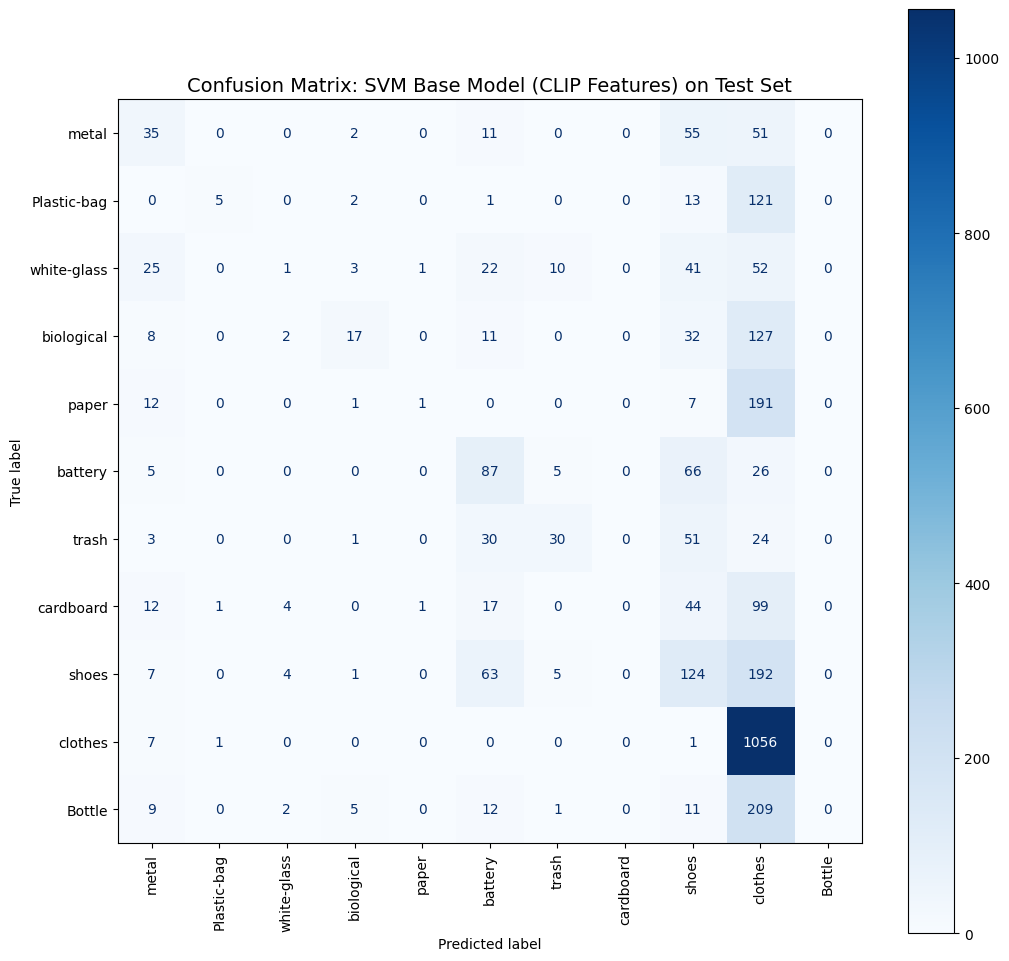


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_baseline_test.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn
num_classes = len(classes)
all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_test, 
    labels=all_labels # Đảm bảo ma trận có kích thước 11x11
)

# 2. Trực quan hóa Ma trận nhầm lẫn
print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST")

# Khởi tạo figure
fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: SVM Base Model (CLIP Features) on Test Set', fontsize=14)


# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_baseline_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 1356 ảnh)


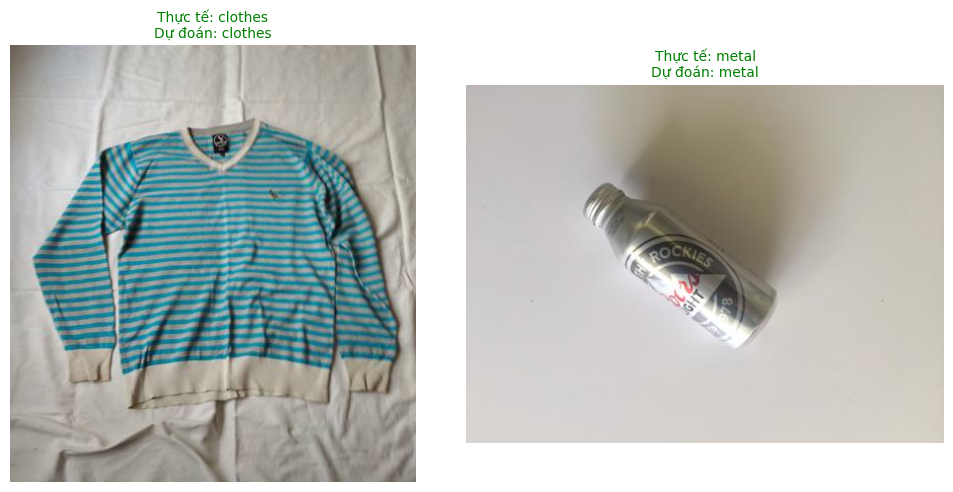

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

correctly_classified_mask = (y_test == y_pred_test)
indices_in_test_set = np.where(correctly_classified_mask)[0]
num_correctly_classified = len(indices_in_test_set)

print(f"HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_correctly_classified} ảnh)")

# Chọn số lượng ảnh muốn hiển thị
num_to_display = min(2, num_correctly_classified) 

#LOGIC CHỌN VÀ HIỂN THỊ (ĐÃ SỬA LỖI return) 

if num_correctly_classified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_correct_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_correct_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu xanh lá cho dự đoán đúng
            title_color = 'green' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Không có bất kỳ mẫu nào được phân loại đúng trong tập Test. Không thể hiển thị hình ảnh.")

HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 1720 ảnh)


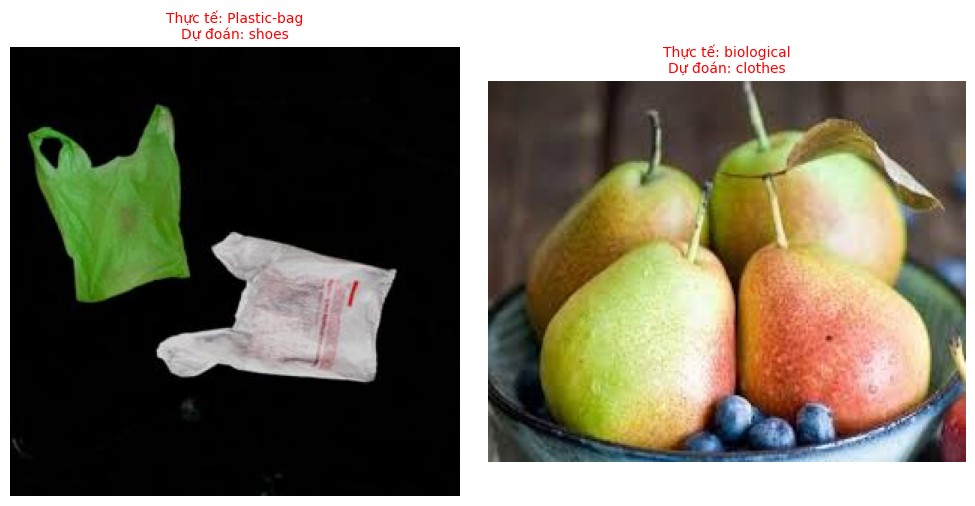

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

# 1. Tìm các chỉ mục (indices) nơi dự đoán SAI
misclassified_mask = (y_test != y_pred_test)
indices_in_test_set = np.where(misclassified_mask)[0]
num_misclassified = len(indices_in_test_set)

print(f"HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_misclassified} ảnh)")

# Chọn số lượng ảnh muốn hiển thị
num_to_display = min(2, num_misclassified) 

# *** LOGIC CHỌN VÀ HIỂN THỊ ***

if num_misclassified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_misclassified_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_misclassified_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu đỏ cho dự đoán sai
            title_color = 'red' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Không có mẫu nào bị phân loại sai trong tập Test. (Chúc mừng! Hoặc kiểm tra lại dữ liệu). Không thể hiển thị hình ảnh.")

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time

# BƯỚC 1: XÁC ĐỊNH LƯỚI THAM SỐ VÀ KHỞI TẠO GRID SEARCH
# Phạm vi các giá trị C và gamma cần thử nghiệm
param_grid = {
    'C': [0.1, 1, 10,100], # Thử nghiệm các giá trị C khác nhau
    'gamma': ['scale', 0.01, 0.1], # Thử nghiệm các giá trị gamma khác nhau
    'kernel': ['rbf'] 
}

base_svm = SVC(random_state=42)

print("="*60)
print("BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN")
print("="*60)
start_time = time.time()

# Grid Search sẽ tìm kiếm tham số tốt nhất qua 3-fold Cross-Validation trên X_train
grid_search = GridSearchCV(
    estimator=base_svm, 
    param_grid=param_grid, 
    cv=3, 
    verbose=2, 
    n_jobs=-1, # Sử dụng tất cả các lõi CPU
    scoring='accuracy' 
)

# Chạy tìm kiếm
grid_search.fit(X_train, y_train)

end_time = time.time()
print(f"\nThời gian chạy Grid Search: {end_time - start_time:.2f} giây")
print("="*60)

# BƯỚC 2: ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST
# Lấy mô hình SVM tốt nhất đã được tối ưu
best_svm_model = grid_search.best_estimator_

print(f"Tham số TỐT NHẤT tìm được: {grid_search.best_params_}")
print(f"Độ chính xác TỐT NHẤT (Cross-Validation trên Train): {grid_search.best_score_:.4f}")
print("-" * 60)

# Dự đoán trên tập Test BẰNG MÔ HÌNH TỐT NHẤT
y_pred_final = best_svm_model.predict(X_test)

# 1. Độ chính xác cuối cùng
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Độ chính xác CUỐI CÙNG trên tập TEST: {final_accuracy:.4f}")

# 2. Báo cáo Phân loại cuối cùng
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\nBáo cáo Phân loại CUỐI CÙNG (Classification Report trên Test):")
print(classification_report(y_test, y_pred_final, target_names=classes, labels=all_labels))
print("="*60)

BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Thời gian chạy Grid Search: 52.21 giây
Tham số TỐT NHẤT tìm được: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Độ chính xác TỐT NHẤT (Cross-Validation trên Train): 0.5419
------------------------------------------------------------
Độ chính xác CUỐI CÙNG trên tập TEST: 0.5491

Báo cáo Phân loại CUỐI CÙNG (Classification Report trên Test):
              precision    recall  f1-score   support

       metal       0.40      0.29      0.34       154
 Plastic-bag       0.49      0.15      0.24       142
 white-glass       0.43      0.33      0.37       155
  biological       0.61      0.32      0.42       197
       paper       0.55      0.27      0.36       212
     battery       0.56      0.60      0.58       189
       trash       0.55      0.29      0.38       139
   cardboard       0.40      0.12      0.19       178
       shoes       0.42      0.38      0.40       

MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST


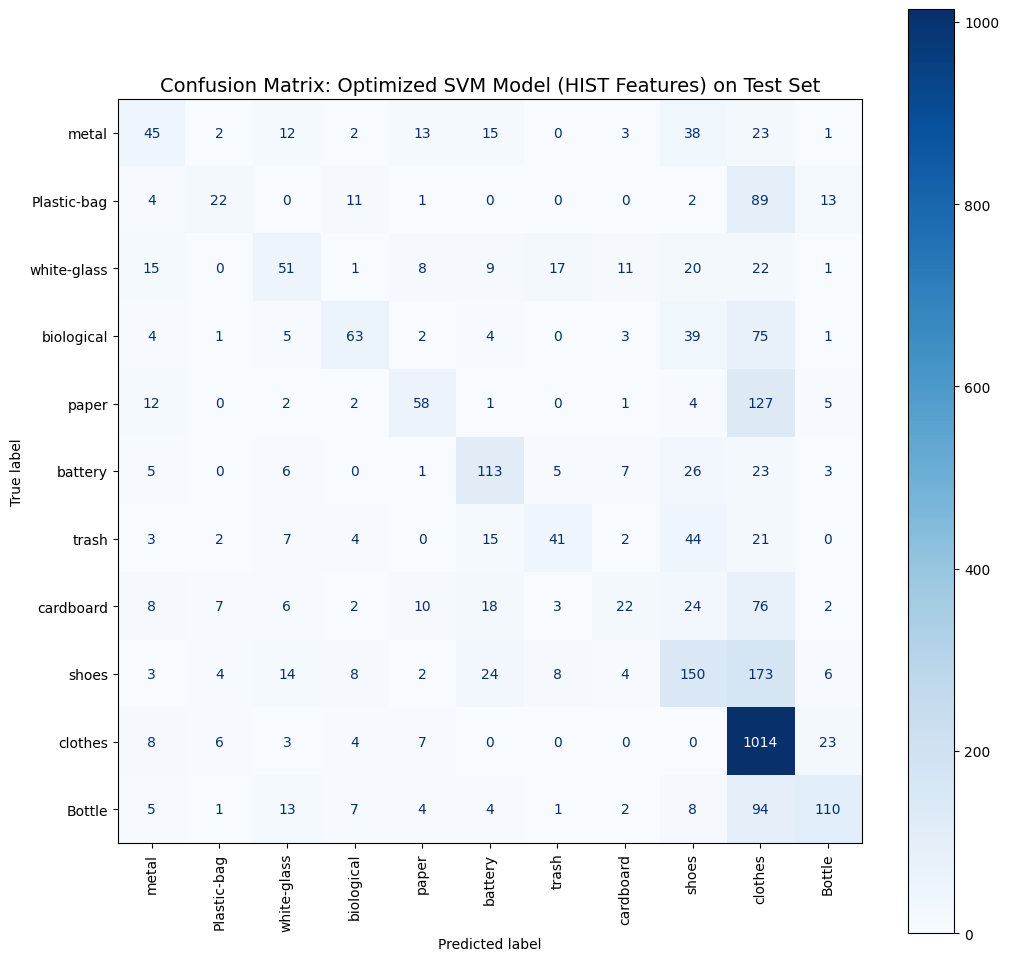


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_optimized_hist_test.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn
num_classes = len(classes)
all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_final, 
    labels=all_labels # Đảm bảo ma trận có kích thước đầy đủ
)

# 2. Trực quan hóa Ma trận nhầm lẫn

print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST")

# Khởi tạo figure
fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes) 

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: Optimized SVM Model (HIST Features) on Test Set', fontsize=14)

# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_optimized_hist_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

In [16]:
import joblib
import os 
import time

timestamp = time.strftime("%Y%m%d_%H%M%S")
file_name = f"best_svm_lbp_model_{timestamp}.joblib"

# BƯỚC 1: LƯU MÔ HÌNH

print(f"BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT")

try:

    joblib.dump(best_svm_model, file_name)
    
    print(f"Mô hình đã được lưu thành công tại: {os.path.abspath(file_name)}")
    print(f"Tham số: {best_svm_model.get_params()}")
except Exception as e:
    print(f"Lỗi khi lưu mô hình: {e}")


BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT
Mô hình đã được lưu thành công tại: /kaggle/working/best_svm_lbp_model_20260119_150422.joblib
Tham số: {'C': 100, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
